# Task 1: Convolutional-Recurrent Architectures

Build a model based on convolutional-recurrent architectures for classifying Style, Artist, Genre, and other attributes. General and Specific. Pick the most appropriate approach and discuss your strategy. Use the ArtGAN dataset: https://github.com/cs-chan/ArtGAN/blob/master/WikiArt%20Dataset/README.md

Evaluation Metrics: discuss which evaluation metrics you are using to evaluate your model performance. Find outliers, e.g. paintings that do not fit a particular artist or genre despite their assignment.

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
from PIL import Image, ImageFile
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.metrics import f1_score, classification_report
import wandb

ImageFile.LOAD_TRUNCATED_IMAGES = True

# wandb login
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
wandb.login(key=secrets.get_secret("WANDB_API_KEY"))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: samanvithkashyap (samanvithkashyap-pes-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 1. Dataset Loader
PyTorch Dataset for the WikiArt Dataset. Returns the 3 labels for style, artist and genre. Handles missing or corrupted images

In [2]:
class WikiArtMultiTask(Dataset):
    
    def __init__(self, style_csv, artist_csv, genre_csv, img_dir, transform=None):
        style_df = pd.read_csv(style_csv, header=None, names=['filename', 'style'])
        artist_df = pd.read_csv(artist_csv, header=None, names=['filename', 'artist'])
        genre_df = pd.read_csv(genre_csv, header=None, names=['filename', 'genre'])
        
        merged = style_df.merge(artist_df, on='filename', how='inner')
        merged = merged.merge(genre_df, on='filename', how='inner')
        
        self.annotations = merged.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        print(f"Loaded {len(self.annotations)} images with all 3 labels "
              f"(style: {self.annotations['style'].nunique()}, "
              f"artist: {self.annotations['artist'].nunique()}, "
              f"genre: {self.annotations['genre'].nunique()})")

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        for attempt in range(min(10, len(self.annotations))):
            try:
                idx = (index + attempt) % len(self.annotations)
                row = self.annotations.iloc[idx]
                img_path = os.path.join(self.img_dir, str(row['filename']))
                
                image = Image.open(img_path).convert("RGB")
                style_label = int(row['style'])
                artist_label = int(row['artist'])
                genre_label = int(row['genre'])

                if self.transform:
                    image = self.transform(image)
                return image, style_label, artist_label, genre_label, img_path
                
            except Exception as e:
                continue
        raise RuntimeError(f"No images found from the dataset")

# 2. Model Architecture
Backbone: EfficientNet-B3
Task specific heads:
*  **Style Head**: Column-wise reshape -> BiGRU (2 layers, hidden=256) -> FC -> 27 classes
*  **Artist Head**: GAP -> FC(1536->512) -> ReLU -> Dropout(0.3) -> FC(512->195)
*  **Genre Head**: GAP -> FC(1536->256) -> ReLU -> Dropout(0.3) -> FC(256->10)
  
 Hierarchy: Genre (10) -> Style (27) -> Artist (195)

In [3]:
# Multi-Task CRNN Architecture
class ArtCRNN(nn.Module):
    def __init__(self, num_styles=27, num_artists=195, num_genres=10):
        super(ArtCRNN, self).__init__()
        
        # Shared Backbone: EfficientNet-B3
        basemodel = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        self.backbone = basemodel.features  # Output: (B, 1536, 8, 8)
        
        # GAP for artist/genre heads
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Style Head: BiGRU on column-wise features
        self.style_rnn_input_dim = 1536 * 8  # channels * height = 12288
        self.style_hidden_size = 256
        self.style_rnn = nn.GRU(
            input_size=self.style_rnn_input_dim,
            hidden_size=self.style_hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.style_fc = nn.Linear(self.style_hidden_size * 2, num_styles)  # BiGRU -> 512 -> 27
        
        # Artist Head: FC with Dropout
        self.artist_head = nn.Sequential(
            nn.Linear(1536, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_artists)
        )
        
        # Genre Head: FC with Dropout 
        self.genre_head = nn.Sequential(
            nn.Linear(1536, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_genres)
        )
        
    def forward(self, x):
        # Shared feature extraction
        features = self.backbone(x)  # (B, 1536, 8, 8)
        batch_size, channels, height, width = features.size()
        
        # --- Style: column-wise reshape -> BiGRU ---
        style_in = features.permute(0, 3, 1, 2).contiguous()  # (B, W, C, H)
        style_in = style_in.view(batch_size, width, channels * height)  # (B, 8, 12288)
        _, style_hidden = self.style_rnn(style_in)
        # Concat last hidden from both directions
        style_out = torch.cat((style_hidden[-2], style_hidden[-1]), dim=1)  # (B, 512)
        style_logits = self.style_fc(style_out)
        
        # --- Artist and Genre: GAP -> FC ---
        pooled = self.gap(features).view(batch_size, -1)  # (B, 1536)
        artist_logits = self.artist_head(pooled)
        genre_logits = self.genre_head(pooled)
        
        return style_logits, artist_logits, genre_logits

# 3. Training
**Phase 1** (10 epochs): Freeze backbone, train only task heads at lr=1e-3  
**Phase 2** (up to 20 epochs): Unfreeze last 3 backbone blocks, fine-tune at lr=1e-4  
- Early stopping: Stops if validation loss doesn't improve for 5 consecutive epochs
- Best model checkpoint is restored at the end

**Multi-Task Loss**: `L = Ls*L_style + La*L_artist + Lg*L_genre`  
- Style: Weighted CrossEntropy (class imbalance), Ls=1.0  
- Artist: CrossEntropy + Label Smoothing e=0.1 (subjective boundaries), La=0.8  
- Genre: Weighted CrossEntropy (class imbalance), Lg=0.8  

Mixed precision (fp16) + CosineAnnealingLR scheduler per phase.
Validation metrics logged after every epoch to wandb for monitoring.

In [4]:
def compute_class_weights(csv_path, label_col, num_classes, device):
    """Compute inverse-frequency weights for imbalanced classes."""
    df = pd.read_csv(csv_path, header=None)
    counts = df[label_col].value_counts().sort_index()
    weights = 1.0 / counts.values.astype(np.float32)
    weights = weights / weights.sum() * num_classes  # normalize
    return torch.tensor(weights, dtype=torch.float32).to(device)


def freeze_backbone(model):
    """Freeze all backbone parameters."""
    for param in model.backbone.parameters():
        param.requires_grad = False


def unfreeze_last_n_blocks(model, n=3):
    """Unfreeze the last n blocks of EfficientNet backbone."""
    # EfficientNet-B3 has 8 blocks (indices 0-7) in .backbone
    blocks = list(model.backbone.children())
    # Unfreeze last n blocks
    for block in blocks[-n:]:
        for param in block.parameters():
            param.requires_grad = True


def evaluate_model(model, val_loader, device, style_criterion, artist_criterion, genre_criterion):
    """Evaluate model on validation set and return metrics."""
    model.eval()
    val_loss = {'style': 0.0, 'artist': 0.0, 'genre': 0.0, 'total': 0.0}
    correct = {'style': 0, 'artist': 0, 'genre': 0}
    total = 0
    
    with torch.no_grad():
        for images, style_labels, artist_labels, genre_labels, _ in val_loader:
            images = images.to(device)
            style_labels = style_labels.to(device)
            artist_labels = artist_labels.to(device)
            genre_labels = genre_labels.to(device)
            
            style_out, artist_out, genre_out = model(images)
            
            loss_style = style_criterion(style_out, style_labels)
            loss_artist = artist_criterion(artist_out, artist_labels)
            loss_genre = genre_criterion(genre_out, genre_labels)
            total_loss = loss_style + 0.8 * loss_artist + 0.8 * loss_genre
            
            val_loss['style'] += loss_style.item()
            val_loss['artist'] += loss_artist.item()
            val_loss['genre'] += loss_genre.item()
            val_loss['total'] += total_loss.item()
            
            _, style_pred = torch.max(style_out, 1)
            _, artist_pred = torch.max(artist_out, 1)
            _, genre_pred = torch.max(genre_out, 1)
            
            total += style_labels.size(0)
            correct['style'] += (style_pred == style_labels).sum().item()
            correct['artist'] += (artist_pred == artist_labels).sum().item()
            correct['genre'] += (genre_pred == genre_labels).sum().item()
    
    n_batches = len(val_loader)
    avg_loss = {k: v / n_batches for k, v in val_loss.items()}
    acc = {k: 100.0 * v / total for k, v in correct.items()}
    
    return avg_loss, acc


def train_model(model, train_loader, val_loader, device, 
                style_weights, genre_weights,
                epochs_phase1=10, epochs_phase2=20,
                lambda_style=1.0, lambda_artist=0.8, lambda_genre=0.8,
                early_stop_patience=5):
    """Two-phase multi-task training with validation monitoring and early stopping."""
    
    # Loss functions
    style_criterion = nn.CrossEntropyLoss(weight=style_weights)
    artist_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    genre_criterion = nn.CrossEntropyLoss(weight=genre_weights)
    
    # For validation (no class weights to get unbiased estimate)
    val_style_criterion = nn.CrossEntropyLoss()
    val_artist_criterion = nn.CrossEntropyLoss()
    val_genre_criterion = nn.CrossEntropyLoss()
    
    scaler = torch.amp.GradScaler('cuda')
    best_val_loss = float('inf')
    best_model_state = None
    
    # ==================== PHASE 1: Frozen Backbone ====================
    print("=" * 60)
    print("PHASE 1: Training heads only (backbone frozen)")
    print("=" * 60)
    
    freeze_backbone(model)
    head_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(head_params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_phase1)
    
    for epoch in range(epochs_phase1):
        model.train()
        running_loss = {'style': 0.0, 'artist': 0.0, 'genre': 0.0, 'total': 0.0}
        progress_bar = tqdm(train_loader, desc=f"P1 Epoch {epoch+1}/{epochs_phase1}")
        
        for images, style_labels, artist_labels, genre_labels, _ in progress_bar:
            images = images.to(device)
            style_labels = style_labels.to(device)
            artist_labels = artist_labels.to(device)
            genre_labels = genre_labels.to(device)
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                style_out, artist_out, genre_out = model(images)
                
                loss_style = style_criterion(style_out, style_labels)
                loss_artist = artist_criterion(artist_out, artist_labels)
                loss_genre = genre_criterion(genre_out, genre_labels)
                
                total_loss = (lambda_style * loss_style + 
                              lambda_artist * loss_artist + 
                              lambda_genre * loss_genre)
            
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss['style'] += loss_style.item()
            running_loss['artist'] += loss_artist.item()
            running_loss['genre'] += loss_genre.item()
            running_loss['total'] += total_loss.item()
            
            progress_bar.set_postfix(
                total=f"{total_loss.item():.3f}",
                s=f"{loss_style.item():.3f}",
                a=f"{loss_artist.item():.3f}",
                g=f"{loss_genre.item():.3f}"
            )
        
        scheduler.step()
        n_batches = len(train_loader)
        avg = {k: v / n_batches for k, v in running_loss.items()}
        
        # Validation
        val_loss, val_acc = evaluate_model(model, val_loader, device,
                                           val_style_criterion, val_artist_criterion, val_genre_criterion)
        
        print(f"P1 Epoch {epoch+1} -- Train: {avg['total']:.4f} | Val: {val_loss['total']:.4f} | "
              f"Val Acc: S={val_acc['style']:.1f}% A={val_acc['artist']:.1f}% G={val_acc['genre']:.1f}%")
        
        wandb.log({
            "phase": 1, "epoch": epoch + 1,
            "train_loss_total": avg['total'],
            "train_loss_style": avg['style'],
            "train_loss_artist": avg['artist'],
            "train_loss_genre": avg['genre'],
            "val_loss_total": val_loss['total'],
            "val_loss_style": val_loss['style'],
            "val_loss_artist": val_loss['artist'],
            "val_loss_genre": val_loss['genre'],
            "val_acc_style": val_acc['style'],
            "val_acc_artist": val_acc['artist'],
            "val_acc_genre": val_acc['genre'],
            "lr": scheduler.get_last_lr()[0]
        })
    
    # ==================== PHASE 2: Fine-tune Last 3 Blocks ====================
    print("\n" + "=" * 60)
    print("PHASE 2: Fine-tuning last 3 backbone blocks (with early stopping)")
    print("=" * 60)
    
    unfreeze_last_n_blocks(model, n=3)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_phase2)
    
    patience_counter = 0
    
    for epoch in range(epochs_phase2):
        model.train()
        running_loss = {'style': 0.0, 'artist': 0.0, 'genre': 0.0, 'total': 0.0}
        progress_bar = tqdm(train_loader, desc=f"P2 Epoch {epoch+1}/{epochs_phase2}")
        
        for images, style_labels, artist_labels, genre_labels, _ in progress_bar:
            images = images.to(device)
            style_labels = style_labels.to(device)
            artist_labels = artist_labels.to(device)
            genre_labels = genre_labels.to(device)
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                style_out, artist_out, genre_out = model(images)
                
                loss_style = style_criterion(style_out, style_labels)
                loss_artist = artist_criterion(artist_out, artist_labels)
                loss_genre = genre_criterion(genre_out, genre_labels)
                
                total_loss = (lambda_style * loss_style + 
                              lambda_artist * loss_artist + 
                              lambda_genre * loss_genre)
            
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss['style'] += loss_style.item()
            running_loss['artist'] += loss_artist.item()
            running_loss['genre'] += loss_genre.item()
            running_loss['total'] += total_loss.item()
            
            progress_bar.set_postfix(
                total=f"{total_loss.item():.3f}",
                s=f"{loss_style.item():.3f}",
                a=f"{loss_artist.item():.3f}",
                g=f"{loss_genre.item():.3f}"
            )
        
        scheduler.step()
        n_batches = len(train_loader)
        avg = {k: v / n_batches for k, v in running_loss.items()}
        
        # Validation
        val_loss, val_acc = evaluate_model(model, val_loader, device,
                                           val_style_criterion, val_artist_criterion, val_genre_criterion)
        
        print(f"P2 Epoch {epoch+1} -- Train: {avg['total']:.4f} | Val: {val_loss['total']:.4f} | "
              f"Val Acc: S={val_acc['style']:.1f}% A={val_acc['artist']:.1f}% G={val_acc['genre']:.1f}%")
        
        wandb.log({
            "phase": 2, "epoch": epochs_phase1 + epoch + 1,
            "train_loss_total": avg['total'],
            "train_loss_style": avg['style'],
            "train_loss_artist": avg['artist'],
            "train_loss_genre": avg['genre'],
            "val_loss_total": val_loss['total'],
            "val_loss_style": val_loss['style'],
            "val_loss_artist": val_loss['artist'],
            "val_loss_genre": val_loss['genre'],
            "val_acc_style": val_acc['style'],
            "val_acc_artist": val_acc['artist'],
            "val_acc_genre": val_acc['genre'],
            "lr": scheduler.get_last_lr()[0]
        })
        
        # Early stopping check
        if val_loss['total'] < best_val_loss:
            best_val_loss = val_loss['total']
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model! Val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"  -> No improvement ({patience_counter}/{early_stop_patience})")
            
            if patience_counter >= early_stop_patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}!")
                break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nRestored best model with val loss: {best_val_loss:.4f}")

# 4. Finding the outliers
Identifies paintings with high multi task loss. An image confused across multiple head is a stronger outlier signal than a single task mistake. 

Uses pre-image loss from all three heads.

In [5]:
def find_outliers(model, val_loader, device, top_k=10):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    outlier_data = []
    seen_paths = set()
    
    with torch.no_grad():
        for images, style_labels, artist_labels, genre_labels, paths in tqdm(val_loader, desc="Hunting Outliers"):
            images = images.to(device)
            style_labels = style_labels.to(device)
            artist_labels = artist_labels.to(device)
            genre_labels = genre_labels.to(device)
            
            style_out, artist_out, genre_out = model(images)
            
            style_loss = criterion(style_out, style_labels)
            artist_loss = criterion(artist_out, artist_labels)
            genre_loss = criterion(genre_out, genre_labels)
            combined_loss = style_loss + artist_loss + genre_loss
            
            style_pred = torch.argmax(style_out, dim=1)
            artist_pred = torch.argmax(artist_out, dim=1)
            genre_pred = torch.argmax(genre_out, dim=1)
            
            for i in range(len(images)):
                path = paths[i]
                if path not in seen_paths:
                    seen_paths.add(path)
                    outlier_data.append({
                        'image_path': path,
                        'true_style': style_labels[i].item(),
                        'pred_style': style_pred[i].item(),
                        'style_loss': style_loss[i].item(),
                        'true_artist': artist_labels[i].item(),
                        'pred_artist': artist_pred[i].item(),
                        'artist_loss': artist_loss[i].item(),
                        'true_genre': genre_labels[i].item(),
                        'pred_genre': genre_pred[i].item(),
                        'genre_loss': genre_loss[i].item(),
                        'combined_loss': combined_loss[i].item(),
                    })
    
    df = pd.DataFrame(outlier_data)
    top_outliers = df.sort_values(by='combined_loss', ascending=False).head(top_k)
    return top_outliers

In [6]:
# paths to csv and dataset
STYLE_TRAIN_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/style_train.csv"
STYLE_VAL_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/style_val.csv"
ARTIST_TRAIN_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/artist_train.csv"
ARTIST_VAL_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/artist_val.csv"
GENRE_TRAIN_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/genre_train.csv"
GENRE_VAL_CSV = "/kaggle/input/datasets/samanvithkashyap/wikicsv/genre_val.csv"
IMG_DIR = "/kaggle/input/datasets/steubk/wikiart"

# Hyperparameters
NUM_STYLES = 27
NUM_ARTISTS = 195
NUM_GENRES = 10
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 4
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
EARLY_STOP_PATIENCE = 5
LAMBDA_STYLE = 1.0
LAMBDA_ARTIST = 0.8
LAMBDA_GENRE = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize wandb
wandb.init(project="artextract-wikiart", name="multitask-crnn-b3", config={
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_phase1": EPOCHS_PHASE1,
    "epochs_phase2": EPOCHS_PHASE2,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "num_styles": NUM_STYLES,
    "num_artists": NUM_ARTISTS,
    "num_genres": NUM_GENRES,
    "architecture": "EfficientNet-B3 + BiGRU (multi-task)",
    "optimizer": "AdamW",
    "lr_phase1": 1e-3,
    "lr_phase2": 1e-4,
    "lambda_style": LAMBDA_STYLE,
    "lambda_artist": LAMBDA_ARTIST,
    "lambda_genre": LAMBDA_GENRE,
    "label_smoothing_artist": 0.1,
})

# Augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets & DataLoaders
train_dataset = WikiArtMultiTask(
    style_csv=STYLE_TRAIN_CSV, artist_csv=ARTIST_TRAIN_CSV, genre_csv=GENRE_TRAIN_CSV,
    img_dir=IMG_DIR, transform=train_transforms
)
val_dataset = WikiArtMultiTask(
    style_csv=STYLE_VAL_CSV, artist_csv=ARTIST_VAL_CSV, genre_csv=GENRE_VAL_CSV,
    img_dir=IMG_DIR, transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

# Class weights for imbalanced tasks 
style_weights = compute_class_weights(STYLE_TRAIN_CSV, 1, NUM_STYLES, device)
genre_weights = compute_class_weights(GENRE_TRAIN_CSV, 1, NUM_GENRES, device)

# Model 
model = ArtCRNN(num_styles=NUM_STYLES, num_artists=NUM_ARTISTS, num_genres=NUM_GENRES).to(device)
wandb.watch(model, log="gradients", log_freq=100)

# Train
# === Model ===
model = ArtCRNN(num_styles=NUM_STYLES, num_artists=NUM_ARTISTS, num_genres=NUM_GENRES).to(device)
wandb.watch(model, log="gradients", log_freq=100)

# === Train ===
print("Starting Multi-Task Training")
train_model(model, train_loader, val_loader, device, 
            style_weights=style_weights, genre_weights=genre_weights,
            epochs_phase1=EPOCHS_PHASE1, epochs_phase2=EPOCHS_PHASE2,
            lambda_style=LAMBDA_STYLE, lambda_artist=LAMBDA_ARTIST, lambda_genre=LAMBDA_GENRE,
            early_stop_patience=EARLY_STOP_PATIENCE)

torch.save(model.state_dict(), "artcrnn_multitask_weights.pth")
print("Model saved: artcrnn_multitask_weights.pth")

# === Outlier Detection ===
top_10 = find_outliers(model, val_loader, device)
top_10.to_csv("top_10_outliers.csv", index=False)

# ==================== EVALUATION ====================
print("\n" + "=" * 60)
print("EVALUATION")
print("=" * 60)

model.eval()
all_style_labels, all_style_preds = [], []
all_artist_labels, all_artist_preds = [], []
all_genre_labels, all_genre_preds = [], []
correct = {'style': 0, 'artist': 0, 'genre': 0, 'artist_top5': 0}
total = 0

with torch.no_grad():
    for images, style_labels, artist_labels, genre_labels, _ in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        style_labels = style_labels.to(device)
        artist_labels = artist_labels.to(device)
        genre_labels = genre_labels.to(device)
        
        style_out, artist_out, genre_out = model(images)
        
        # Top-1 predictions
        _, style_pred = torch.max(style_out, 1)
        _, artist_pred = torch.max(artist_out, 1)
        _, genre_pred = torch.max(genre_out, 1)
        
        # Top-5 for artist
        _, artist_top5 = artist_out.topk(5, dim=1)
        artist_top5_correct = artist_top5.eq(artist_labels.unsqueeze(1)).any(dim=1)
        
        total += style_labels.size(0)
        correct['style'] += (style_pred == style_labels).sum().item()
        correct['artist'] += (artist_pred == artist_labels).sum().item()
        correct['genre'] += (genre_pred == genre_labels).sum().item()
        correct['artist_top5'] += artist_top5_correct.sum().item()
        
        all_style_labels.extend(style_labels.cpu().numpy())
        all_style_preds.extend(style_pred.cpu().numpy())
        all_artist_labels.extend(artist_labels.cpu().numpy())
        all_artist_preds.extend(artist_pred.cpu().numpy())
        all_genre_labels.extend(genre_labels.cpu().numpy())
        all_genre_preds.extend(genre_pred.cpu().numpy())

# === F1 Scores ===
style_f1 = f1_score(all_style_labels, all_style_preds, average='weighted')
artist_f1 = f1_score(all_artist_labels, all_artist_preds, average='weighted')
genre_f1 = f1_score(all_genre_labels, all_genre_preds, average='weighted')
avg_f1 = (style_f1 + artist_f1 + genre_f1) / 3.0

# === Accuracies ===
style_acc = 100 * correct['style'] / total
artist_acc = 100 * correct['artist'] / total
artist_top5_acc = 100 * correct['artist_top5'] / total
genre_acc = 100 * correct['genre'] / total

print(f"\n{'Task':<12} {'Accuracy':>10} {'Weighted F1':>12}")
print("-" * 36)
print(f"{'Style':<12} {style_acc:>9.2f}% {style_f1:>11.4f}")
print(f"{'Artist':<12} {artist_acc:>9.2f}% {artist_f1:>11.4f}")
print(f"{'Artist@5':<12} {artist_top5_acc:>9.2f}%")
print(f"{'Genre':<12} {genre_acc:>9.2f}% {genre_f1:>11.4f}")
print("-" * 36)
print(f"{'AVG F1':<12} {'':>10} {avg_f1:>11.4f}")

# === Per-class reports ===
style_names = sorted([d for d in os.listdir(IMG_DIR) 
                      if os.path.isdir(os.path.join(IMG_DIR, d))])

# Get unique labels present in validation data
unique_style_labels = sorted(set(all_style_labels) | set(all_style_preds))
unique_genre_labels = sorted(set(all_genre_labels) | set(all_genre_preds))

print(f"\n--- Style Classification Report ({len(unique_style_labels)} classes present in validation) ---")
print(classification_report(all_style_labels, all_style_preds, 
                            labels=unique_style_labels,
                            target_names=[style_names[i] for i in unique_style_labels], 
                            digits=4, zero_division=0))

print(f"\n--- Genre Classification Report ({len(unique_genre_labels)} classes present in validation) ---")  
print(classification_report(all_genre_labels, all_genre_preds, 
                            labels=unique_genre_labels, digits=4, zero_division=0))

# === Log everything to wandb ===
wandb.log({
    "val_style_acc": style_acc,
    "val_style_f1": style_f1,
    "val_artist_acc": artist_acc,
    "val_artist_top5_acc": artist_top5_acc,
    "val_artist_f1": artist_f1,
    "val_genre_acc": genre_acc,
    "val_genre_f1": genre_f1,
    "val_avg_f1": avg_f1,
})

# Per-class style F1 to wandb
style_f1_per_class = f1_score(all_style_labels, all_style_preds, labels=unique_style_labels, average=None, zero_division=0)
for i, label_idx in enumerate(unique_style_labels):
    wandb.log({f"f1_style_{style_names[label_idx]}": style_f1_per_class[i]})

wandb.finish()

wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260311_011902-9yweqlsn
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run multitask-crnn-b3
wandb: ⭐️ View project at https://wandb.ai/samanvithkashyap-pes-university/artextract-wikiart
wandb: 🚀 View run at https://wandb.ai/samanvithkashyap-pes-university/artextract-wikiart/runs/9yweqlsn


Loaded 11276 images with all 3 labels (style: 16, artist: 23, genre: 10)
Loaded 4707 images with all 3 labels (style: 16, artist: 23, genre: 10)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 179MB/s]


Starting Multi-Task Training
PHASE 1: Training heads only (backbone frozen)


P1 Epoch 1/10: 100%|██████████| 353/353 [03:23<00:00,  1.73it/s, a=2.040, g=0.925, s=0.764, total=3.135]


...

Hunting Outliers: 100%|██████████| 148/148 [01:02<00:00,  2.36it/s]



EVALUATION


Evaluating: 100%|██████████| 148/148 [01:02<00:00,  2.37it/s]
wandb: updating run metadata



Task           Accuracy  Weighted F1
------------------------------------
Style            78.65%      0.7870
Artist           83.51%      0.8333
Artist@5         96.98%
Genre            77.08%      0.7708
------------------------------------
AVG F1                       0.7970

--- Style Classification Report (16 classes present in validation) ---
                        precision    recall  f1-score   support

Abstract_Expressionism     0.0000    0.0000    0.0000         4
     Analytical_Cubism     0.6250    0.7143    0.6667        14
    Art_Nouveau_Modern     0.7200    0.6626    0.6901       163
               Baroque     0.8544    0.9167    0.8844       192
                Cubism     0.6218    0.6271    0.6245       118
         Expressionism     0.4096    0.4302    0.4196       179
               Fauvism     0.0000    0.0000    0.0000        11
         Impressionism     0.8887    0.8759    0.8822      1458
 Naive_Art_Primitivism     0.8272    0.8061    0.8165       196
  North

wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:                           epoch ▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb: f1_style_Abstract_Expressionism ▁
wandb:      f1_style_Analytical_Cubism ▁
wandb:     f1_style_Art_Nouveau_Modern ▁
wandb:                f1_style_Baroque ▁
wandb:                 f1_style_Cubism ▁
wandb:          f1_style_Expressionism ▁
wandb:                f1_style_Fauvism ▁
wandb:          f1_style_Impressionism ▁
wandb:  f1_style_Naive_Art_Primitivism ▁
wandb:                             +28 ...
wandb: 
wandb: Run summary:
wandb:                           epoch 26
wandb: f1_style_Abstract_Expressionism 0
wandb:      f1_style_Analytical_Cubism 0.66667
wandb:     f1_style_Art_Nouveau_Modern 0.6901
wandb:                f1_style_Baroque 0.88442
wandb:                 f1_style_Cubism 0.62447
wandb:          f1_style_Expressionism 0.41962
wandb:                f1_style_Fauvism 0
wandb:          f1_style_Impressionism 0.88221
wandb:  f1_style_Naive_Art_Primi

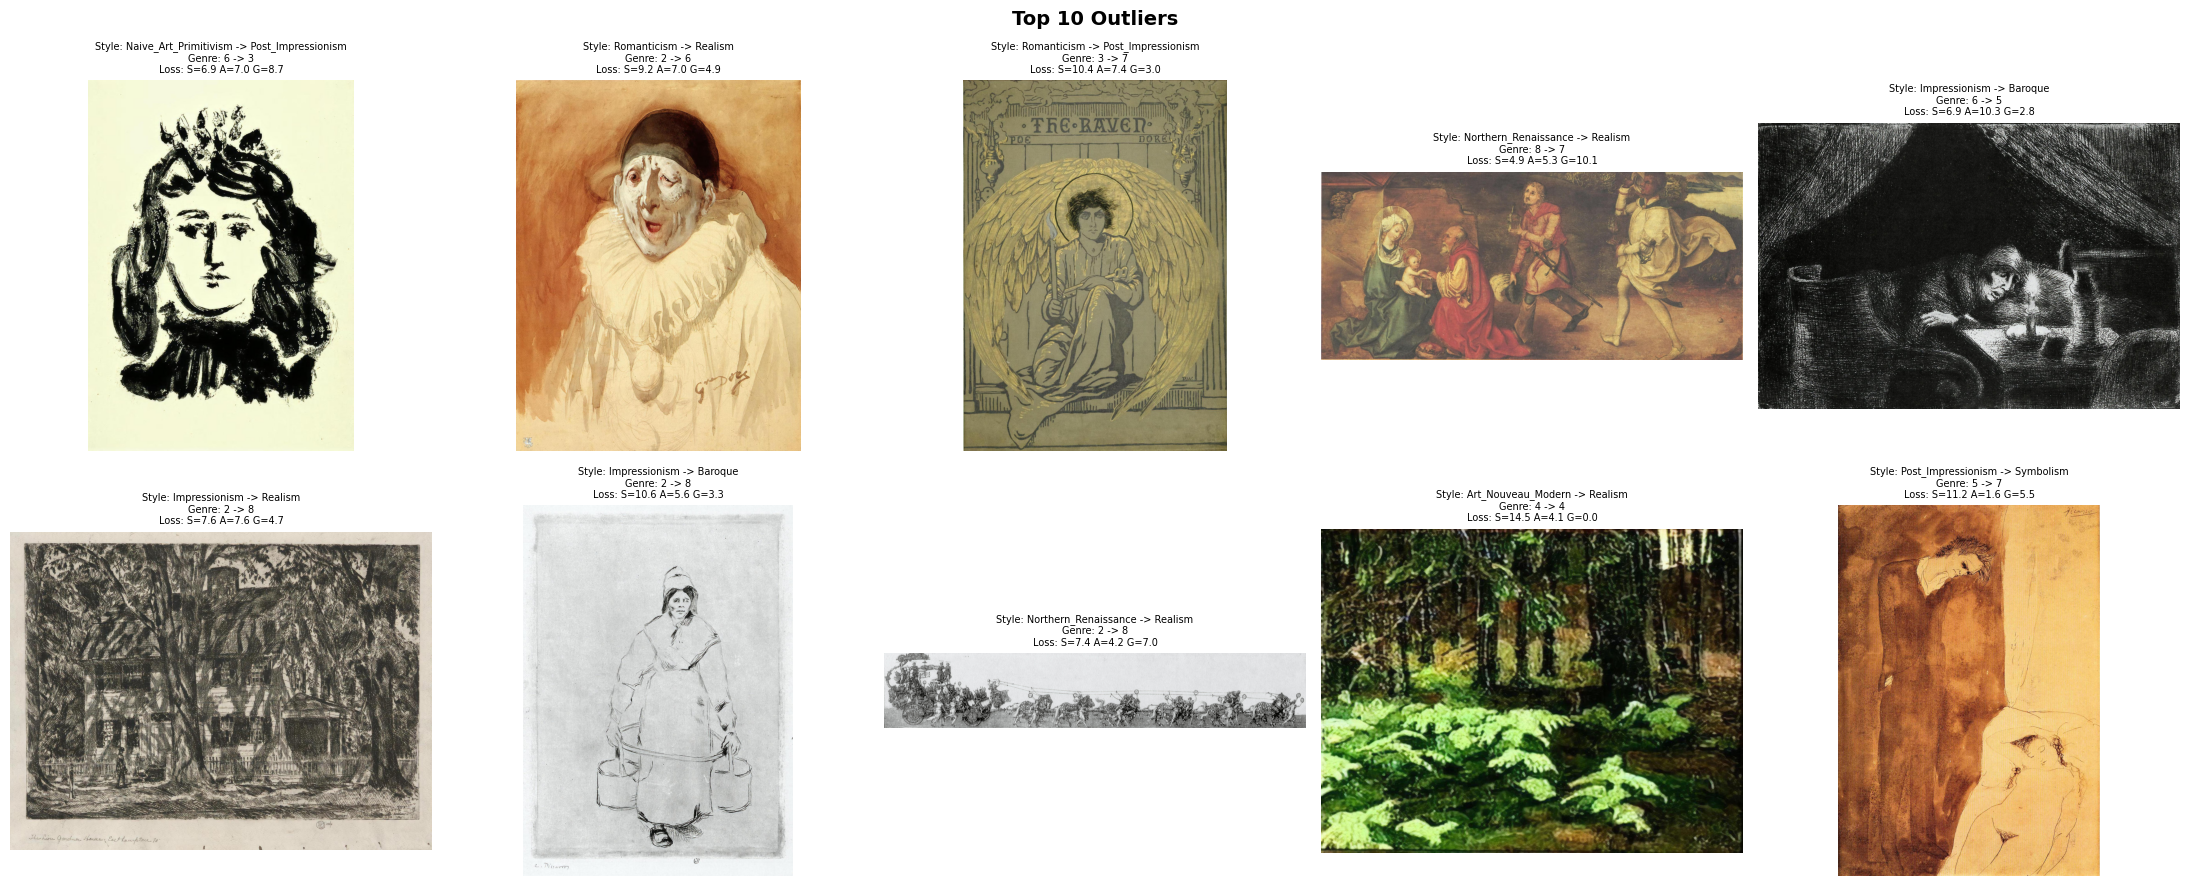

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

style_names = sorted([d for d in os.listdir('/kaggle/input/datasets/steubk/wikiart') 
                      if os.path.isdir(os.path.join('/kaggle/input/datasets/steubk/wikiart', d))])

for idx, (_, row) in enumerate(top_10.iterrows()):
    img_path = os.path.join('/kaggle/input/datasets/steubk/wikiart', row['image_path'])
    img = Image.open(img_path)
    axes[idx].imshow(img)
    
    title = (f"Style: {style_names[row['true_style']]} -> {style_names[row['pred_style']]}\n"
             f"Genre: {row['true_genre']} -> {row['pred_genre']}\n"
             f"Loss: S={row['style_loss']:.1f} A={row['artist_loss']:.1f} G={row['genre_loss']:.1f}")
    
    axes[idx].set_title(title, fontsize=7)
    axes[idx].axis('off')

plt.suptitle('Top 10 Outliers', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_multitask.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Strategy Discussion and Results

### Architecture Choice: Why CRNN over pure CNN or ViT?
- **Pure CNN** (ResNet, EfficientNet + FC): Treats the image as a bag of features. 
  Loses spatial ordering of brushstrokes -- critical for distinguishing Impressionism 
  from Post-Impressionism where technique differs but palette overlaps.
- **Vision Transformer**: Requires large datasets (>300k) to outperform CNNs. 
  WikiArt's 81k images with 195 artist classes would likely overfit.
- **CRNN (our approach)**: CNN extracts spatial features, RNN captures sequential 
  patterns across canvas columns -- best fit for style where texture repetition matters.

### Why Multi-Task over Separate Models?
- Shared backbone learns **general visual features** that benefit all tasks
- Genre (general: 10 classes) acts as a **regularizer** for the more specific heads
- 3x parameter efficiency -- one backbone instead of three
- Style <-> Artist correlation provides **implicit data augmentation** 
  (knowing an artist helps predict style)

### General vs. Specific Hierarchy
| Level | Task | Classes | Head Design | Metric |
|-------|------|---------|-------------|--------|
| General | Genre | 10 | Small FC + Weighted XEnt | Weighted F1 |
| Specific | Style | 27 | BiGRU + Weighted XEnt | Weighted F1 |
| Most Specific | Artist | 195 | FC + Label Smoothing | Top-5 Acc + Weighted F1 |

### Multi-Task Loss Weights
Ls=1.0 (primary task), La=0.8, Lg=0.8.
Style weighted highest because it is the core task; artist and genre provide 
supporting signal without dominating gradients.

### Evaluation
- **3 separate Weighted F1 scores** (one per task) -- each task has its own label space
- **Average F1** across all three tasks as a single summary metric
- **Top-5 accuracy** for Artist since many artists share visual similarity
- Per-class classification reports for Style and Genre